<a href="https://colab.research.google.com/github/above-avg/pap-smear-binary-classifier-92acc/blob/main/binary_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

data_dir = '/content/drive/MyDrive/pap-smear/dataset/herlev/binary'
print("Classes:", os.listdir(data_dir))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Classes: ['normal', 'abnormal']


In [ ]:
import shutil

local_dir = '/content/dataset'
if not os.path.exists(local_dir):
    shutil.copytree('/content/drive/MyDrive/pap-smear/dataset/herlev/binary', local_dir)
    print("Dataset copied to local runtime storage.")

data_dir = local_dir


In [ ]:
# Image preprocessing and augmentation
IMG_SIZE = 224
BATCH_SIZE = 16

from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load dataset
dataset = datasets.ImageFolder(data_dir, transform=train_transforms)
class_names = dataset.classes
print("Detected classes:", class_names)

# Split 80–20 into train/val
train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")


Detected classes: ['abnormal', 'normal']
Train samples: 1467, Val samples: 367


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = models.resnet18(weights='IMAGENET1K_V1')
num_features = model.fc.in_features
model.fc = nn.Sequential(nn.Dropout(0.4),nn.Linear(num_features, 2))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Using device: cuda


In [ ]:
EPOCHS = 15
for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total

    # Validation
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = 100 * val_correct / val_total
    print(f"Epoch [{epoch+1}/{EPOCHS}] | "
          f"Train Loss: {running_loss/len(train_loader):.4f} | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")


Epoch [1/15] | Train Loss: 0.4334 | Train Acc: 80.85% | Val Acc: 87.74%
Epoch [2/15] | Train Loss: 0.3155 | Train Acc: 88.00% | Val Acc: 90.19%
Epoch [3/15] | Train Loss: 0.2813 | Train Acc: 89.03% | Val Acc: 89.92%
Epoch [4/15] | Train Loss: 0.2444 | Train Acc: 90.59% | Val Acc: 90.46%
Epoch [5/15] | Train Loss: 0.2048 | Train Acc: 92.23% | Val Acc: 90.74%
Epoch [6/15] | Train Loss: 0.1891 | Train Acc: 92.23% | Val Acc: 90.46%
Epoch [7/15] | Train Loss: 0.1847 | Train Acc: 92.64% | Val Acc: 87.47%
Epoch [8/15] | Train Loss: 0.1860 | Train Acc: 92.64% | Val Acc: 90.74%
Epoch [9/15] | Train Loss: 0.1709 | Train Acc: 93.87% | Val Acc: 89.37%
Epoch [10/15] | Train Loss: 0.1468 | Train Acc: 94.48% | Val Acc: 89.37%
Epoch [11/15] | Train Loss: 0.1399 | Train Acc: 94.82% | Val Acc: 92.37%
Epoch [12/15] | Train Loss: 0.1306 | Train Acc: 95.30% | Val Acc: 88.56%
Epoch [13/15] | Train Loss: 0.1378 | Train Acc: 95.09% | Val Acc: 92.10%
Epoch [14/15] | Train Loss: 0.1078 | Train Acc: 96.32% | Val

In [ ]:
save_path = '/content/drive/MyDrive/pap-smear/models'
os.makedirs(save_path, exist_ok=True)
torch.save(model.state_dict(), f"{save_path}/resnet18_binary_raw_generalized_5epoch.pth")
print(" Model saved to Drive.")


In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import numpy as np
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_paths = {
    "Denoised (-d)": "/content/drive/MyDrive/pap-smear/models/resnet18_binary_92acc.pth",
    "Raw BMP 15 epoch": "/content/drive/MyDrive/pap-smear/models/resnet18_binary_raw_92accgeneralized_15epoch.pth",
    "Raw BMP": "/content/drive/MyDrive/pap-smear/models/resnet18_binary_rawacc.pth"
}

results = {}

for name, path in model_paths.items():
    print(f"\n🔹 Evaluating model: {name}")

    state_dict = torch.load(path, map_location=device)

    has_dropout_head = any(k.startswith("fc.1") for k in state_dict.keys())

    model = models.resnet18(weights=None)
    num_features = model.fc.in_features

    if has_dropout_head:
        print("→ Detected dropout head (Sequential).")
        model.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(num_features, 2)
        )
    else:
        print("→ Detected plain linear head.")
        model.fc = nn.Linear(num_features, 2)


    model.load_state_dict(state_dict, strict=True)
    model = model.to(device)
    model.eval()

    # Evaluate
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred) * 100
    f1 = f1_score(y_true, y_pred, average='macro')
    cm = confusion_matrix(y_true, y_pred)

    results[name] = {
        "Accuracy": acc,
        "F1": f1,
        "Confusion": cm,
        "Report": classification_report(y_true, y_pred, target_names=['Normal', 'Abnormal'], digits=3)
    }

# Comparison Table
print("\n=== Model Comparison ===")
for name, r in results.items():
    print(f"\n{name}:")
    print(f"  Accuracy: {r['Accuracy']:.2f}%")
    print(f"  F1-score: {r['F1']:.3f}")
    print("  Confusion matrix:\n", r['Confusion'])



🔹 Evaluating model: Denoised (-d)
→ Detected plain linear head.

🔹 Evaluating model: Raw BMP 15 epoch
→ Detected dropout head (Sequential).

🔹 Evaluating model: Raw BMP
→ Detected plain linear head.

=== Model Comparison ===

Denoised (-d):
  Accuracy: 92.37%
  F1-score: 0.895
  Confusion matrix:
 [[265  10]
 [ 18  74]]

Raw BMP 15 epoch:
  Accuracy: 92.37%
  F1-score: 0.890
  Confusion matrix:
 [[271   4]
 [ 24  68]]

Raw BMP:
  Accuracy: 91.28%
  F1-score: 0.881
  Confusion matrix:
 [[262  13]
 [ 19  73]]


In [ ]:
!pip install grad-cam --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 46.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


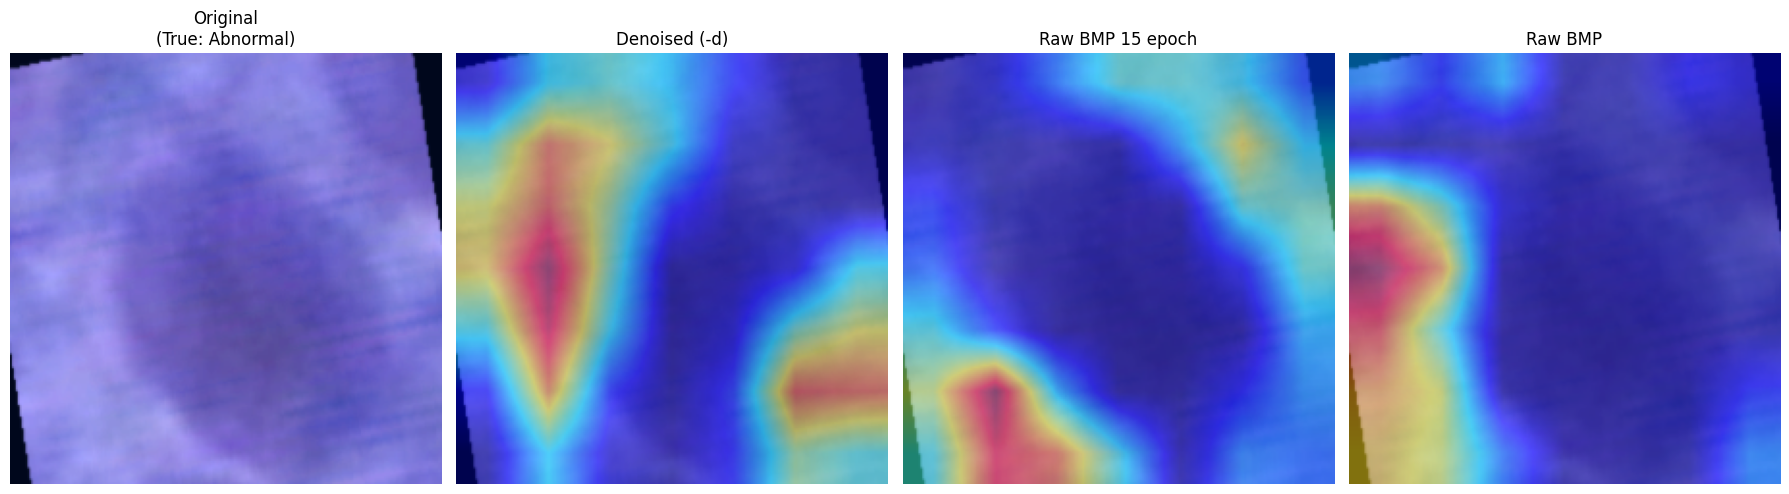

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms, models
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import torch
import torch.nn as nn
from random import choice

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


val_iter = iter(val_loader)
sample_inputs, sample_labels = next(val_iter)
idx = choice(range(len(sample_inputs)))
input_img = sample_inputs[idx]
true_label = sample_labels[idx].item()

# convert tensor -> numpy image
rgb_img = input_img.permute(1, 2, 0).cpu().numpy()
rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

# run GradCAM and return overlay
def generate_cam(model, image_tensor):
    target_layer = model.layer4[-1]
    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=image_tensor.unsqueeze(0).to(device),
                        targets=[ClassifierOutputTarget(1)])  # 1 = Abnormal
    cam_image = show_cam_on_image(rgb_img, grayscale_cam[0], use_rgb=True)
    cam.__del__()  # explicitly release hooks
    return cam_image

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(rgb_img)
axes[0].set_title(f"Original\n(True: {'Abnormal' if true_label else 'Normal'})")
axes[0].axis('off')

for i, (name, path) in enumerate(model_paths.items(), start=1):
    state_dict = torch.load(path, map_location=device)
    has_dropout_head = any(k.startswith("fc.1") for k in state_dict.keys())

    model = models.resnet18(weights=None)
    num_features = model.fc.in_features
    if has_dropout_head:
        model.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(num_features, 2))
    else:
        model.fc = nn.Linear(num_features, 2)

    model.load_state_dict(state_dict, strict=False)
    model = model.to(device)
    model.eval()

    cam_img = generate_cam(model, input_img)
    axes[i].imshow(cam_img)
    axes[i].set_title(name)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

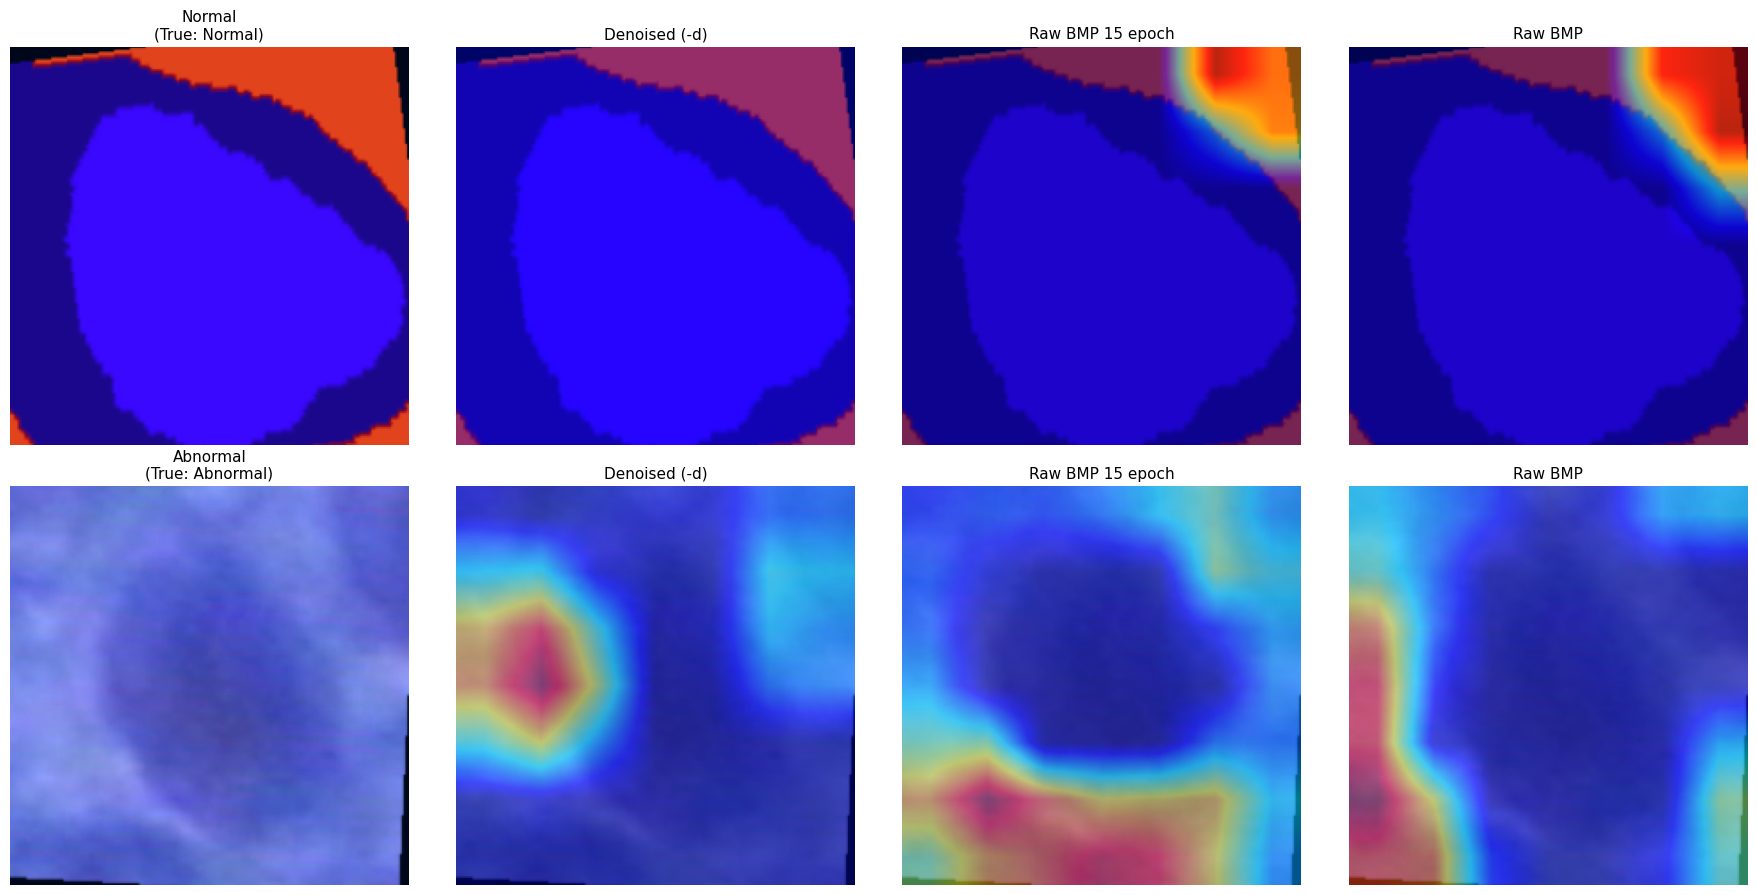

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms, models
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Pick one Normal and one Abnormal sample ----
normal_idx, abnormal_idx = None, None
for inputs, labels in val_loader:
    for i, label in enumerate(labels):
        if label.item() == 0 and normal_idx is None:
            normal_img = inputs[i]
            normal_label = label.item()
            normal_idx = True
        elif label.item() == 1 and abnormal_idx is None:
            abnormal_img = inputs[i]
            abnormal_label = label.item()
            abnormal_idx = True
        if normal_idx and abnormal_idx:
            break
    if normal_idx and abnormal_idx:
        break

samples = [("Normal", normal_img, normal_label), ("Abnormal", abnormal_img, abnormal_label)]

def generate_cam(model, image_tensor):
    rgb_img = image_tensor.permute(1, 2, 0).cpu().numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())
    target_layer = model.layer4[-1]
    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=image_tensor.unsqueeze(0).to(device),
                        targets=[ClassifierOutputTarget(1)])  # focus on 'Abnormal' class
    cam_image = show_cam_on_image(rgb_img, grayscale_cam[0], use_rgb=True)
    cam.__del__()  # release hooks
    return cam_image

# ---- Build models + generate GradCAMs ----
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for row_idx, (title, img_tensor, true_lbl) in enumerate(samples):
    rgb_img = img_tensor.permute(1, 2, 0).cpu().numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

    # Original
    axes[row_idx, 0].imshow(rgb_img)
    axes[row_idx, 0].set_title(f"{title}\n(True: {title})", fontsize=11)
    axes[row_idx, 0].axis("off")

    # For each model
    for col_idx, (model_name, path) in enumerate(model_paths.items(), start=1):
        state_dict = torch.load(path, map_location=device)
        has_dropout_head = any(k.startswith("fc.1") for k in state_dict.keys())

        model = models.resnet18(weights=None)
        num_features = model.fc.in_features
        if has_dropout_head:
            model.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(num_features, 2))
        else:
            model.fc = nn.Linear(num_features, 2)
        model.load_state_dict(state_dict, strict=False)
        model.to(device).eval()

        cam_img = generate_cam(model, img_tensor)
        axes[row_idx, col_idx].imshow(cam_img)
        axes[row_idx, col_idx].set_title(model_name, fontsize=11)
        axes[row_idx, col_idx].axis("off")

plt.tight_layout()
plt.show()